<a href="https://colab.research.google.com/github/vmaltseva17/idleovmt/blob/main/assignment1_vmt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Mount drive and run imports
from google.colab import drive
drive.mount("/content/gdrive")


Mounted at /content/gdrive


In [2]:
# @title Importing Necessary Packages

# import torchvision.transforms as transforms
from torchvision.transforms import v2
import torchvision.datasets as datasets
import torch.utils.data as data
import copy

import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import numbers
import torch

import pandas as pd
import os

from pathlib import Path

from torch.utils.data import Dataset, DataLoader
import rasterio

# function to ensure reproducibility by fixing random state
def set_seed(seed_value):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

In [3]:
# @title Save path

# Modify 'save_dir' to the path to download MNIST dataset.
save_dir = "your_directory"

In [5]:
## Answer here (5 points)
# using the mean and standard deviation values of the MNSTI dataset as per provided in the assignmenet
# we are going to use these to normalize the pixel values of the images
mnist_mean = 0.13066048920154572
mnist_std = 0.30810779333114624

#v2.compose creates one transformation pipeline by applying each
#transformation in the order randomrotation, randomcrop, toimage and then toDtype
#this pipeline will then be applied to the training images

train_transforms = v2.Compose([

#random rotation randomly rotates each training image by up to 5 degrees
#in either direction
#fill=0 fills any empty pixels created by the rotation with 0(black)
#this is augmentation where this will give the model slightly different versions of
#the training images so it does not rely on digits that always have the same orientation
v2.RandomRotation(degrees=5, fill=0),

#random crop randomly crops the image to a size of 28x28 pixels
#padding=2 first adds 2 pixels of padding around the image which
#allows the random crop to move around the digit and still return a 28x28 image
#this is also a form of data augmentation
v2.RandomCrop(size=28, padding=2),

#toimage coberts the input into torchvision's image representation so that the following v2 transformations can consistently operate on it
v2.ToImage(),

#ToDtype converts image values to torch.float32, which is the numerical data type commonly used for neural
#network inputs
#scale = true scales integer image values into floating point values
v2.ToDtype(torch.float32, scale=True),

#Normalize standardizes the image using the provided MNIST mean and standard deviation
#this puts pixel values on a standardized scale before they are passed into a nueral network
v2.Normalize(mean=[mnist_mean], std=[mnist_std])

])

#then creating the transformation pipeline for the test / validation images
#these have to be normalized, data type converted, and format converted but we do not augmentate them

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[mnist_mean], std=[mnist_std])
])

#this is creating a variable called train_transforms, inside which is a compose objest
#the output of one transformation becomes the input of the next transformation
#augmentation is done to improve training


In [8]:
#step 2
#using assigned data set, split original data 90/10, and validation has to have different transformations from training

#MNIST comes with 60,000 images training pool and 10,000 images test pool

#training data is what the network learns from and then the model will change its weights based on the
#mistakes it has made on these examples
#validation data is not used in training, and then used to check how well the model
#performs on data its not actively learning from

#first complete 60,000 image training pool
#datasets were imported
#.MNIST to create a dataset object
train_data = datasets.MNIST(
    #telling PyTorch to store the MNIST files in the folder represented by save dir
    root=save_dir,
    #getting MNISTs training pool
    train=True,
    #if MNIST is not already stored at save_dir, download it
    download=True,
    #whenever u grab a training image from the dataset, process it using the train transforms pipeline
    transform=train_transforms
)
#creating the test dataset
test_data = datasets.MNIST(
    root=save_dir,
    train=False,
    download=True,
    #for no augmentation
    transform=test_transforms
)

#applying the specified calculations
train_ratio = 0.9
n_total = len(train_data)
n_train=int(n_total*train_ratio)
n_validate = n_total - n_train

#randomly splitting train data into two pieces containing n train and n validate
#reassinging the train data variable so it only refers to the 54,000 image subset
train_data, validate_data=data.random_split(
    train_data,
    [n_train, n_validate]
)
#randomsplit does not make two independently MNIST datasets
#the subsets still reference the same underlying dataset
#make a deep copy so we can treat them independently
validate_data = copy.deepcopy(validate_data)
#accessing the underlying MNIST dataset inside that subset
#accessing that datasets transformation pipeline
#and replacing it with non augmented test pipeline
validate_data.dataset.transform = test_transforms

#confusion: example output shows random rotation and random crop
#under validation as well but instructions say to remove it
#going to follow instructions

#step 3 make data loaders.
#created 3 datasets, wrap each dataset in a dataloader which controls how pytorch gives
#those images to us.
#dataloaders orgnaizes dataset examples into iterable batches
#iterable means moving through one batch at a time
batch_size = 50
#this is so everyone's results are reproducible
#essentially starting from the same predefined random state
set_seed(1)
#variable train loader to contain data loader object
#accesing Pytorch's dataloader class so it can create oe
train_loader = data.DataLoader(
    #this is the dataset it should load from
    train_data,
    batch_size=50,
    #randomize the order of the training examples
    #because we dont want the model to learn from examples in the exact same fixed sequence every epoch
    shuffle=True
)
#creating the validation dataloader but shuffle is false because not training on validation data so need to randomise

validation_loader = data.DataLoader(
    validate_data,
    batch_size = 50,
    shuffle = False
)

test_loader = data.DataLoader(
    test_data,
    batch_size = 50,
    shuffle = False
)

print(test_loader.dataset.data[0][5:10, 5:10])
print(train_loader.dataset.dataset.data[0][5:10, 5:10])
print(validation_loader.dataset.dataset.data[0][5:10, 5:10])




100%|██████████| 9.91M/9.91M [00:01<00:00, 5.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.54MB/s]


tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0],
        [  0,  84, 185, 159, 151],
        [  0, 222, 254, 254, 254],
        [  0,  67, 114,  72, 114]], dtype=torch.uint8)
tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,  30,  36],
        [  0,   0,  49, 238, 253],
        [  0,   0,  18, 219, 253],
        [  0,   0,   0,  80, 156]], dtype=torch.uint8)
tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,  30,  36],
        [  0,   0,  49, 238, 253],
        [  0,   0,  18, 219, 253],
        [  0,   0,   0,  80, 156]], dtype=torch.uint8)


Text(0.5, 1.0, 'Label: 1')

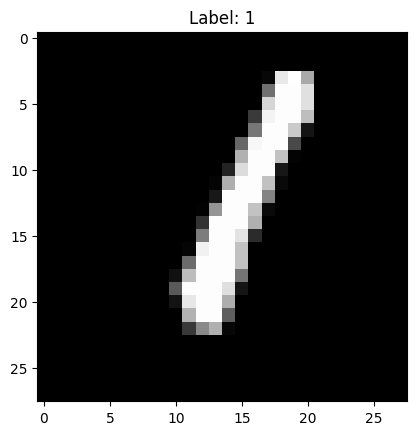

In [10]:
#step 4: asking train loader for one batch of 50 images and labels, select the second
#imafe and its corresponding label, remove an unnecessary dimension and display it using mat plot lib
#iter creates an iterator that will allow python to move through the images one at time
train_iterator = iter(train_loader)
#getting first batch
images, labels = next(train_iterator)
#batch, channels, height, width, this is represented by 4 numbers
#MNIST is grayscale so there is only one channel
idx = 1
#bc python starts counting at 0
#taking the image located at 1 from this batch
image = images[idx]
label = labels[idx]
#when you remove the batch dimension you select only 1 image
#matplot lib does not have grayscale channel dimension
image = image.squeeze()
#imshow is used to display an array as an image
#cmap means display the values using a grayscale color map
plt.imshow(image, cmap="gray")
#label is a pytorch tensor containing a single number, .item will extract that number
plt.title(f"Label: {label.item()}")

#its generating 5 but thats ok bc the label matches the number
#lowk that does not look like a five but ok






In [23]:
src_dir = "/content/gdrive/MyDrive"
csv_path = "/content/gdrive/MyDrive/mappingafrica-256/catalog.csv"

catalog = pd.read_csv(csv_path)
catalog.head()


,name,dataset,version,country,x,y,fld_prop,nonfld_prop,null_prop,window_a,window_b,mask,split
0,AO0632385,mappingafrica,v2.0.0,AO,17.7865,-8.5125,0.098633,0.901367,0.0,NaN,mappingafrica-256/images/AO0632385_2022-11.tif,mappingafrica-256/labels/AO0632385_13723_2022-...,test
1,AO0848301,mappingafrica,v2.0.0,AO,13.6515,-9.1375,0.232502,0.767498,0.0,NaN,mappingafrica-256/images/AO0848301_2018-08.tif,mappingafrica-256/labels/AO0848301_5032_2018-0...,train
2,AO0896141,mappingafrica,v2.0.0,AO,15.7365,-9.2725,0.525590,0.474410,0.0,NaN,mappingafrica-256/images/AO0896141_2020-11.tif,mappingafrica-256/labels/AO0896141_6106_2020-1...,train
3,AO1006914,mappingafrica,v2.0.0,AO,15.7365,-9.5925,0.024374,0.975626,0.0,NaN,mappingafrica-256/images/AO1006914_2020-11.tif,mappingafrica-256/labels/AO1006914_21105_2020-...,train
4,AO1031101,mappingafrica,v2.0.0,AO,15.7515,-9.6625,0.962133,0.037867,0.0,NaN,mappingafrica-256/images/AO1031101_2021-11.tif,mappingafrica-256/labels/AO1031101_26851_2021-...,train


In [13]:
#@title Input normalization
def min_max_normalize_image(image, dtype=np.float32):
    """
    image_path(str) -- Absolute path to the image patch.
    dtype (numpy datatype) -- data type of the normalized image default is
    "np.float32".
    """

    # Calculate the minimum and maximum values for each band
    min_values = np.nanmin(image, axis=(1, 2))[:, np.newaxis, np.newaxis]
    max_values = np.nanmax(image, axis=(1, 2))[:, np.newaxis, np.newaxis]

    # Normalize the image data to the range [0, 1]
    normalized_img = (image - min_values) / (max_values - min_values)
    # normalized_img = normalized_img.astype(dtype)

    # Return the normalized image data
    return normalized_img

In [14]:
#@title Rotation transformation (`cv2`)
def rotate_image_and_label(image, label, angle):
    """
    Applies rotation augmentation to an image patch and label.

    Args:
        image (numpy array) : The input image patch as a numpy array.
        label (numpy array) : The corresponding label as a numpy array.
        angle (lost of floats) : If the list has exactly two elements they will
            be considered the lower and upper bounds for the rotation angle
            (in degrees) respectively. If number of elements are bigger than 2,
            then one value is chosen randomly as the roatation angle.

    Returns:
        A tuple containing the rotated image patch and label as numpy arrays.
    """
    if isinstance(angle, tuple) or isinstance(angle, list):
        if len(angle) == 2:
            rotation_degree = random.uniform(angle[0], angle[1])
        elif len(angle) > 2:
            rotation_degree = random.choice(angle)
        else:
            raise ValueError("Parameter degree needs at least two elements.")
    else:
        raise ValueError(
            "Rotation bound param for augmentation must be a tuple or list."
        )

    # Define the center of the image patch
    center = tuple(np.array(label.shape)/2.0)

    # Define the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_degree, 1.0)

    # Apply rotation augmentation to the image patch
    rotated_image = cv2.warpAffine(image, rotation_matrix, image.shape[:2],
                                   flags=cv2.INTER_LINEAR)

    # Apply rotation augmentation to the label
    rotated_label = cv2.warpAffine(label, rotation_matrix, label.shape[:2],
                                   flags=cv2.INTER_NEAREST)

    # Return the rotated image patch and label as a tuple
    return rotated_image.copy(), np.rint(rotated_label.copy())

In [15]:
#@title Rotation transformation (`cv2`)
def rotate_image_and_label(image, label, angle):
    """
    Applies rotation augmentation to an image patch and label.

    Args:
        image (numpy array) : The input image patch as a numpy array.
        label (numpy array) : The corresponding label as a numpy array.
        angle (lost of floats) : If the list has exactly two elements they will
            be considered the lower and upper bounds for the rotation angle
            (in degrees) respectively. If number of elements are bigger than 2,
            then one value is chosen randomly as the roatation angle.

    Returns:
        A tuple containing the rotated image patch and label as numpy arrays.
    """
    if isinstance(angle, tuple) or isinstance(angle, list):
        if len(angle) == 2:
            rotation_degree = random.uniform(angle[0], angle[1])
        elif len(angle) > 2:
            rotation_degree = random.choice(angle)
        else:
            raise ValueError("Parameter degree needs at least two elements.")
    else:
        raise ValueError(
            "Rotation bound param for augmentation must be a tuple or list."
        )

    # Define the center of the image patch
    center = tuple(np.array(label.shape)/2.0)

    # Define the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_degree, 1.0)

    # Apply rotation augmentation to the image patch
    rotated_image = cv2.warpAffine(image, rotation_matrix, image.shape[:2],
                                   flags=cv2.INTER_LINEAR)

    # Apply rotation augmentation to the label
    rotated_label = cv2.warpAffine(label, rotation_matrix, label.shape[:2],
                                   flags=cv2.INTER_NEAREST)

    # Return the rotated image patch and label as a tuple
    return rotated_image.copy(), np.rint(rotated_label.copy())

In [16]:
## Answer here: Modify the requested parts (20 points)

class ActiveLoadingDataset(Dataset):
    def __init__(self, src_dir, csv_path, split,
                 apply_normalization=True, transform=None, **kargs):

        r"""
        src_dir (str or path) : Root of resource directory.
        csv_path (str) : Directory of the csv file containing the input paths.
        split (str) : Either 'train' or 'validate'.
        transform (list) : Each element is string name of the transformation
            to be used, e.g. ["rotate", "flip"].
        """

        self.src_dir = src_dir
        self.csv_path = csv_path
        self.transform = transform
        self.apply_normalization = apply_normalization

        self.split = split
        assert self.split in ["train", "validate"], "Split is not recognized."

        # Load catalog and subset by split
        catalog = pd.read_csv(Path(self.csv_path))
        self.catalog = catalog[catalog.split == self.split].reset_index(drop=True)

        # Store paths (images are already chipped)
        self.img_paths = self.catalog["window_b"]
        self.lbl_paths = self.catalog["mask"]


    def __getitem__(self, index):

        # Load image chip
        # Make sure channel is last dimension (H, W, C)
        img_path = self.img_paths.iloc[index]
        #rasterio reads remote sensing data
        #c = 4 bands
        # h = image height
        # w image width
        #rasterio.open() to open the satellite image files
        #read to read the four bands
        #initially will return as c h w
        with rasterio.open(Path(self.src_dir)/img_path) as src:
          img = src.read()

        #then changing the image from c h w to h w c as specified
        img = img.transpose((1, 2, 0))


        # Load label chip (H, W)
        lbl_path = self.lbl_paths.iloc[index]
        with rasterio.open(Path(self.src_dir) / lbl_path) as src:
          label = src.read(1)
        #the label mask is one layer
        #each pixel in the mask reprsents:
        #0 non crop
        #1 crop field interior
        #2 field boundary
        #the input is an image and the output identifies a class for each pixel
        #2D array with shape h, w


        # Apply normalization if requested
        if self.apply_normalization:
            img =  img.transpose((2, 0, 1))
            #static function provided, maps values onto range [0,1]
            #function expects c h w so temporarily transpose image
            #then transpose back
            img = min_max_normalize_image(img)
            img = img.transpose((1,2,0))

        # Data augmentation (training only)
        if self.split == "train" and self.transform:

            # Add your augmentation logic here.
            # If applying flipping, randomly choose the flip direction.

            #applying rotation randomly

            if random.randint(0, 1) > 0.5 and "rotate"  in self.transform:
                img, label = rotate_image_and_label(
                    img,
                    label,
                    [-10, 10]
                )

            #applying flipping randomly
            if random.random() > 0.5 and "flip" in self.transform:
              #flip direction has to be randomly selected between horizontal and vertical
              flip_type = random.choice(["hflip", "vflip"])
              img, label = flip_image_and_label(
                    img,
                    label,
                    flip_type
                )
        # Convert numpy arrays to torch tensors
        # Image must be CHW
        image_tensor = torch.from_numpy(
            img.transpose((2, 0, 1))
        ).float()

        label_tensor = torch.from_numpy(
            np.ascontiguousarray(label)
        ).long()

        return image_tensor, label_tensor


    def __len__(self):
        # Return the number of samples in this split
        return  len(self.catalog)

In [20]:
#@title Plot random pairs from the Pytorch customDataset object.

def show_random_pairs(dataset, sample_num, rgb_bands):
    # basic checks
    if not (isinstance(sample_num, int) and 1 <= sample_num <= len(dataset)):
        raise ValueError("sample_num must be between 1 and len(dataset).")

    if not (isinstance(rgb_bands, (tuple, list)) and len(rgb_bands) == 3):
        raise ValueError("rgb_bands must be a tuple/list of length 3.")

    r, g, b = rgb_bands
    nrow, ncol = sample_num, 2

    fig, axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(16, 6 * nrow),
                            squeeze=False)

    sample_indices = random.sample(range(len(dataset)), k=sample_num)

    for i, idx in enumerate(sample_indices):
        x, y = dataset[idx]          # x: (C,H,W), y: (H,W)
        x = x.cpu()
        y = y.cpu()

        # build RGB (H,W,3)
        rgb = torch.stack([x[r], x[g], x[b]], dim=0).permute(1, 2, 0)

        # if values look like 0..1 keep as float; otherwise scale for display
        if (rgb.max() - rgb.min()) > 1:
            rgb = rgb.int()

        axs[i, 0].set_title(f"Image #{idx}")
        axs[i, 0].imshow(rgb)
        axs[i, 0].axis("off")

        axs[i, 1].set_title(f"Label #{idx}")
        axs[i, 1].imshow(y)
        axs[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

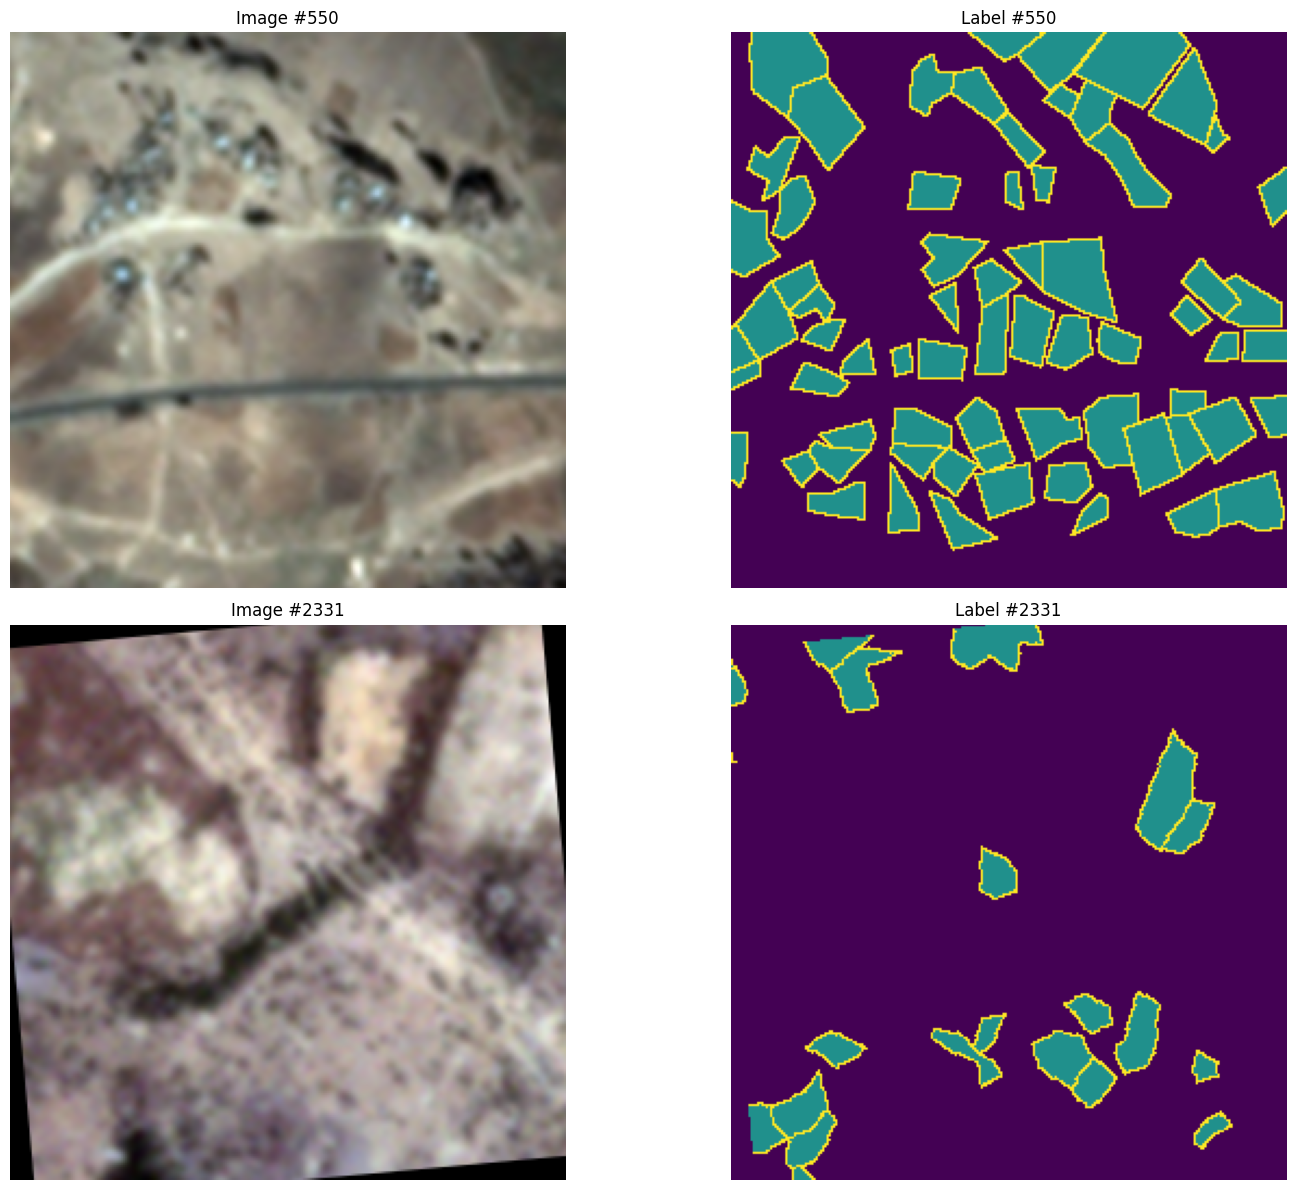

In [24]:
#setting random seed to 1 before creating and visualizing the datasets
#makes random operations reproducible,meajning the the same random choices can be produced again when the code is rerun
set_seed(1)

#create training dataset using a custom activeloading dataset class
train_dataset = ActiveLoadingDataset(
    #root directory where image and label files are stores
    src_dir=src_dir,

    #path to the CSV catalog that contains image paths, mask paths and info abt which split each sample belongs to
    csv_path=csv_path,

    #only use rows in the catalog that belong to the training split
    split = "train",

    #apply the min max normalization
    apply_normalization=True,

    #both of the augmentations can be used on the training images and their masks
    transform = ["rotate", "flip"]
)
#creating validation dataset using the same class
validate_dataset = ActiveLoadingDataset(
    #the validation images come from the same root data directory
    src_dir = src_dir,
    #use same csv catalog
    csv_path=csv_path,
    #this time only rows that belong to the validation split
    split = "validate",
    #normalize validation images
    apply_normalization=True,
    #but no random augmentation to data
    transform = None

)

#then visualizing 2 randomly selected image label pairs from the training dataset
#telling it which three bands should be displayed as red green and blue channels
show_random_pairs(
    train_dataset,
    sample_num=2,
    rgb_bands=(0,1,2)
)


In [26]:
## Answer here (30 points)

class ActiveLoadingDatasetDirect(Dataset):
    """
    Directory-driven dataset for *already-chipped* remote sensing imagery.
    (No CSV. Train/validate split is created on-the-fly.)

    Dataset root (fixed):
        Path(src_dir) / "mappingafrica-256"

    Expects folders inside mappingafrica-256:
        images/   (image chips)
        labels/   (label/mask chips)

    Pairing rule (your filenames):
        image: AO0632385_2022-11.tif
        label: AO0632385_13723_2022-11.tif
      -> label has an extra token in the middle (e.g., 13723)
      -> match by (prefix, suffix) = (first token, last token) split by "_"

    Returns:
      image_tensor: float32, shape (C, H, W)
      label_tensor: int64,   shape (H, W)
    """

    def __init__(self, src_dir, split,
                 train_ratio=0.8, seed=42,
                 apply_normalization=True, transform=None,
                 image_suffix=".tif", label_suffix=".tif",
                 **kargs):

        # TODO 1: DIRECTORY ROOT (instead of CSV)
        # Set the dataset root

        self.src_dir = Path(src_dir) / "mappingafrica-256"


        self.transform = transform
        self.apply_normalization = apply_normalization

        self.split = split
        assert self.split in ["train", "validate"], "Split is not recognized."

        # TODO 2: READ FROM DIRECTORIES
        # Create paths for:
        #(note that in mappingafrica-256 folder there are 2 subfolders
        # named images and labels)
        img_dir =  self.src_dir/"images"
        lbl_dir =  self.src_dir/"labels"

        # Optional: raise helpful errors if folders don’t exist
        # if not img_dir.exists(): raise FileNotFoundError(...)
        # if not lbl_dir.exists(): raise FileNotFoundError(...)

        # Use Path.glob to collect all .tif files and sort them
        #glob will find files matching the given suffix and sorted will keep the file order consistnet
        img_files =  sorted(img_dir.glob(f"*{image_suffix}"))
        lbl_files =  sorted(lbl_dir.glob(f"*{label_suffix}"))
        # TODO 3: PAIRING RULE (prefix + suffix)
        # Build a lookup dict for labels keyed by:
        #   key = (first_token, last_token)
        # where tokens come from: lp.stem.split("_")
        lbl_lookup =  {}
        #go through every label file
        for lp in lbl_files:
          #stem will get filename without tiff and split will get _
          tokens = lp.stem.split("_")
          key = (tokens[0], tokens[-1])
          lbl_lookup[key] = lp

        # Build all_pairs = list of (image_path, label_path)
        all_pairs = []
        for ip in img_files:
            # 1) split ip.stem by "_"
            tokens = ip.stem.split("_")
            # 2) build key = (first_token, last_token)
            key = (tokens[0], tokens[-1])
            # 3) find matching label in lbl_lookup
            if key in lbl_lookup:
              #store matching image and label together
              all_pairs.append((ip, lbl_lookup[key]))
            # 4) append to all_pairs if match exists


        # if len(all_pairs) == 0: raise ValueError("No pairs matched...")

        # TODO 4: TRAIN/VALIDATE SPLIT ON THE FLY
        # Use numpy RNG with a seed:
        rng = np.random.default_rng(seed)
        #creating a random ordering of all the image label pair indices
        perm = rng.permutation(len(all_pairs))
        #calculating how many pairs have to go to the training set
        # then:
        n_train = int(len(all_pairs) * train_ratio)
        #first portion of shuffled indices goes to training
        train_idx = perm[:n_train]
        #the rest will go to validation
        valid_idx = perm[n_train:]
        #then choosing the correct indices depedning if the dataset object represents training or validation split
        # finally:
        #   self.pairs = the chosen pairs for this split
        chosen_idx = train_idx if self.split == "train" else valid_idx
        self.pairs = [all_pairs[i] for i in chosen_idx]


        # NOTE: Use the SAME loading/normalization/augmentation
        # logic as the previous assignment.

        self.images = []
        self.labels = []
        for img_path, lbl_path in self.pairs:

            # Load image chip (same as previous task)
            with rasterio.open(img_path) as src:
              img = src.read()
            img = img.transpose((1,2,0))

            # Load label chip (same as previous task)
            with rasterio.open(lbl_path) as src:
              label =  src.read(1)
            # Apply normalization if requested (same as previous task)
            if self.apply_normalization:
                img =  img.transpose((2,0,1))
                img = min_max_normalize_image(img)
                img = img.transpose((1,2,0))

            self.images.append(img)
            self.labels.append(label)


    def __getitem__(self, index):

        img = self.images[index].copy()
        label = self.labels[index].copy()

        # Data augmentation (training only) — same as previous task
        if self.split == "train" and self.transform:

            if random.randint(0, 1) and "rotate" in self.transform:
                img, label = rotate_image_and_label(img, label, angle=[-10, 10])

            if random.random() > 0.5 and "flip" in self.transform:
                flip_type = random.choice(["hflip", "vflip"])
                img, label = flip_image_and_label(img, label, flip_type)

        # Convert numpy arrays to torch tensors (same as previous task)
        image_tensor = torch.from_numpy(
            img.transpose((2, 0, 1))
        ).float()

        label_tensor = torch.from_numpy(
            np.ascontiguousarray(label)
        ).long()

        return image_tensor, label_tensor


    def __len__(self):
        # Return the number of samples in this split
        return  len(self.pairs)

In [ ]:
#setting random seed to 1
set_seed(1)

#creating the training dataset using the direct folder loader
training_dataset = ActiveLoadingDatasetDirect(
    src_dir=src_dir,
    #using the training portion of the on the fly split
    split = "train",
    train_ratio =0.8,
    seed=42,
    #applying min max normalization to images
    apply_normalizations = True,
    #allow rotation and flipping agumentation on training data
    transform =["rotate", "flip"]
)
#same thing for validatoion
validate_dataset = ActiveLoadingDatasetDirect(
    src_dir=src_dir,
    split="validate",
    train_ratio=0.8,
    seed=42,
    apply_normalization=True,
    transform=None
)
#visualizing two random images
show_random_pairs(
    train_dataset,
    sample_num=2,
    rgb_bands=(0, 1, 2)
)






In [29]:
print("Total rows in catalog:", len(catalog))


Total rows in catalog: 4000
